In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score)


In [2]:
# Load the dataset
df = pd.read_csv("breast_cancer.csv")
print(df.head())
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())


   mean radius  mean texture  ...  worst fractal dimension  target
0        17.99         10.38  ...                  0.11890       0
1        20.57         17.77  ...                  0.08902       0
2        19.69         21.25  ...                  0.08758       0
3        11.42         20.38  ...                  0.17300       0
4        20.29         14.34  ...                  0.07678       0

[5 rows x 31 columns]
Shape: (569, 31)
Columns: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 

In [3]:
print(df.tail())


     mean radius  mean texture  ...  worst fractal dimension  target
564        21.56         22.39  ...                  0.07115       0
565        20.13         28.25  ...                  0.06637       0
566        16.60         28.08  ...                  0.07820       0
567        20.60         29.33  ...                  0.12400       0
568         7.76         24.54  ...                  0.07039       1

[5 rows x 31 columns]


In [4]:
print(df.info())
print(df.describe())
print("Missing values:")
print(df.isnull().sum().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

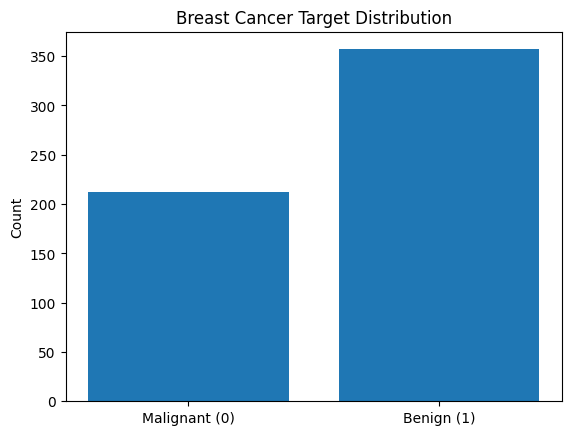

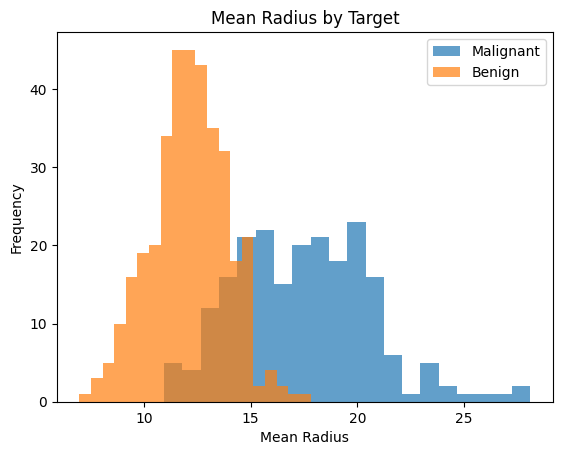

In [5]:
# EDA
counts = df["target"].value_counts().sort_index()
plt.bar(["Malignant (0)", "Benign (1)"], counts.values)
plt.title("Breast Cancer Target Distribution")
plt.ylabel("Count")
plt.show()

plt.hist(df[df["target"] == 0]["mean radius"], bins=20, alpha=0.7, label="Malignant")
plt.hist(df[df["target"] == 1]["mean radius"], bins=20, alpha=0.7, label="Benign")
plt.title("Mean Radius by Target")
plt.xlabel("Mean Radius")
plt.ylabel("Frequency")
plt.legend()
plt.show()


In [6]:
# Select features and target
X = df.drop("target", axis=1)
y = df["target"]

print("Features:", X.shape)
print("Target:", y.shape)
print("Missing values in X:", X.isnull().sum().sum())


Features: (569, 30)
Target: (569,)
Missing values in X: 0


In [7]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 455
Testing samples: 114


In [8]:
# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Feature scaling completed")


Feature scaling completed


In [9]:
# Logistic Regression
model = LogisticRegression(max_iter=1000, C=1.0)
model.fit(X_train_scaled, y_train)
print("Model training completed")

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]
print("First 20 predictions:", y_pred[:20])


Model training completed
First 20 predictions: [0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 1 1]


In [10]:
# Model Evaluation
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy, 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Malignant", "Benign"]))


Accuracy: 0.9825

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



Confusion Matrix:
[[41  1]
 [ 1 71]]


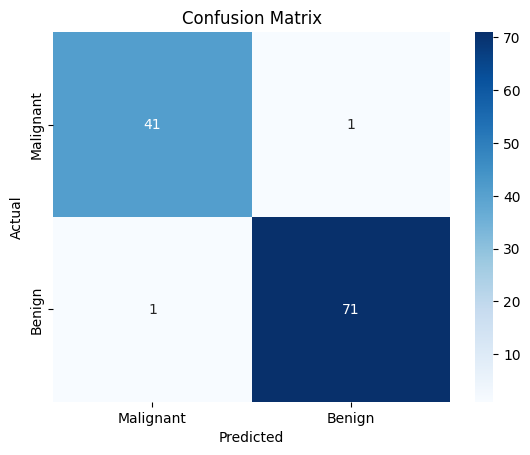

In [11]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Malignant", "Benign"],
            yticklabels=["Malignant", "Benign"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


ROC-AUC Score: 0.9954


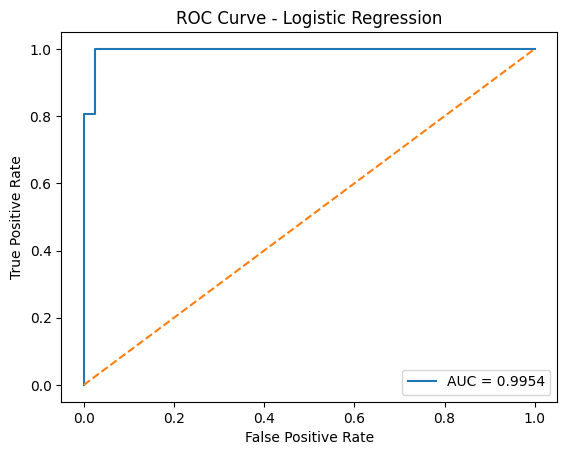

In [12]:
# ROC Curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", round(auc_score, 4))

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()


In [13]:
# Regularisation note
print("Logistic Regression uses L2 regularisation by default in scikit-learn.")
print("C = 1.0 is the inverse of regularisation strength.")
print("Smaller C -> stronger regularisation; larger C -> weaker regularisation.")


Logistic Regression uses L2 regularisation by default in scikit-learn.
C = 1.0 is the inverse of regularisation strength.
Smaller C -> stronger regularisation; larger C -> weaker regularisation.


In [14]:
# Final result
print("Experiment 5 completed successfully.")
print("Logistic Regression Accuracy:", round(accuracy, 4))
print("Logistic Regression ROC-AUC:", round(auc_score, 4))


Experiment 5 completed successfully.
Logistic Regression Accuracy: 0.9825
Logistic Regression ROC-AUC: 0.9954
